In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_column", 100)

In [3]:
df = pd.read_csv("./StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [6]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [7]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

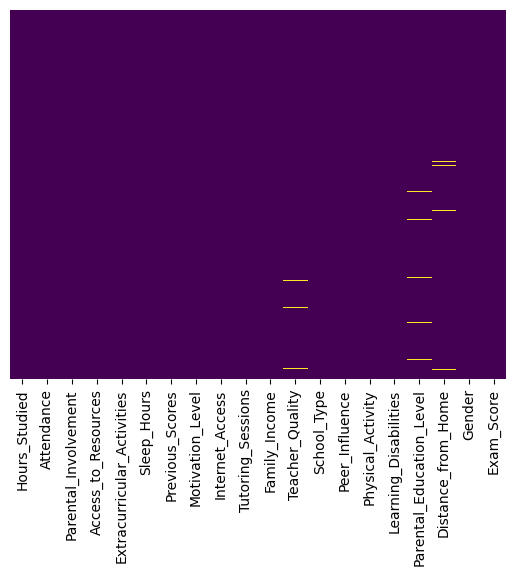

In [8]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

In [9]:
# 78 nan
df['Teacher_Quality'].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [10]:
df['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

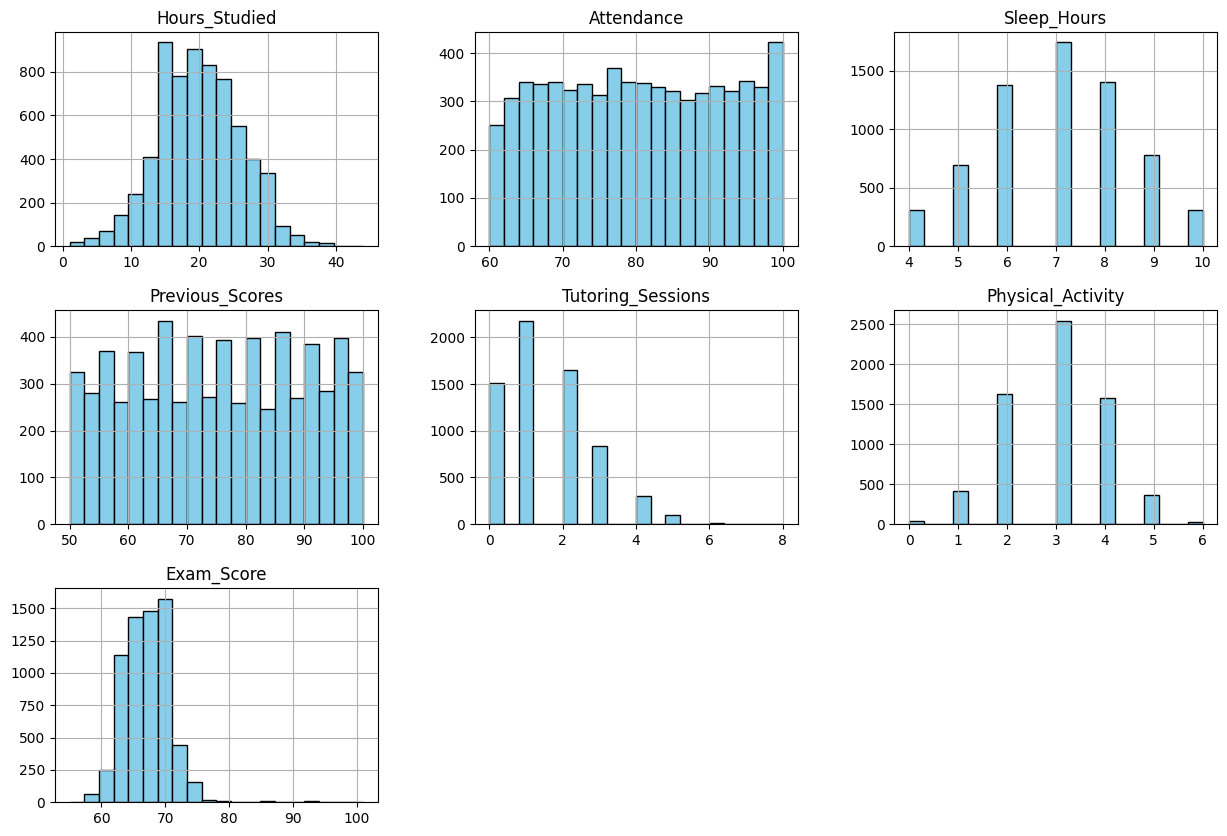

In [11]:
df.hist(bins=20, figsize=(15,10), color='skyblue', edgecolor="black")
plt.show()

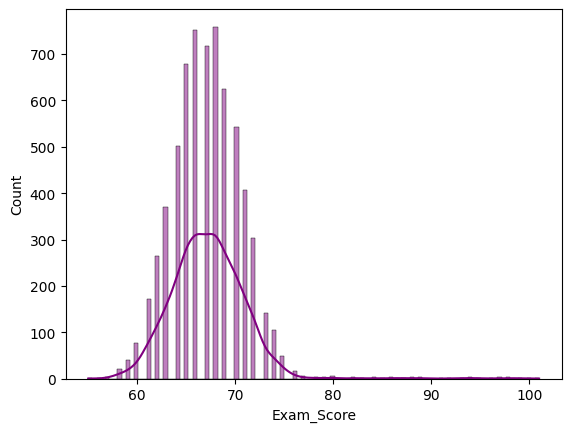

In [12]:
sns.histplot(df['Exam_Score'], kde=True, color='purple')
plt.show()

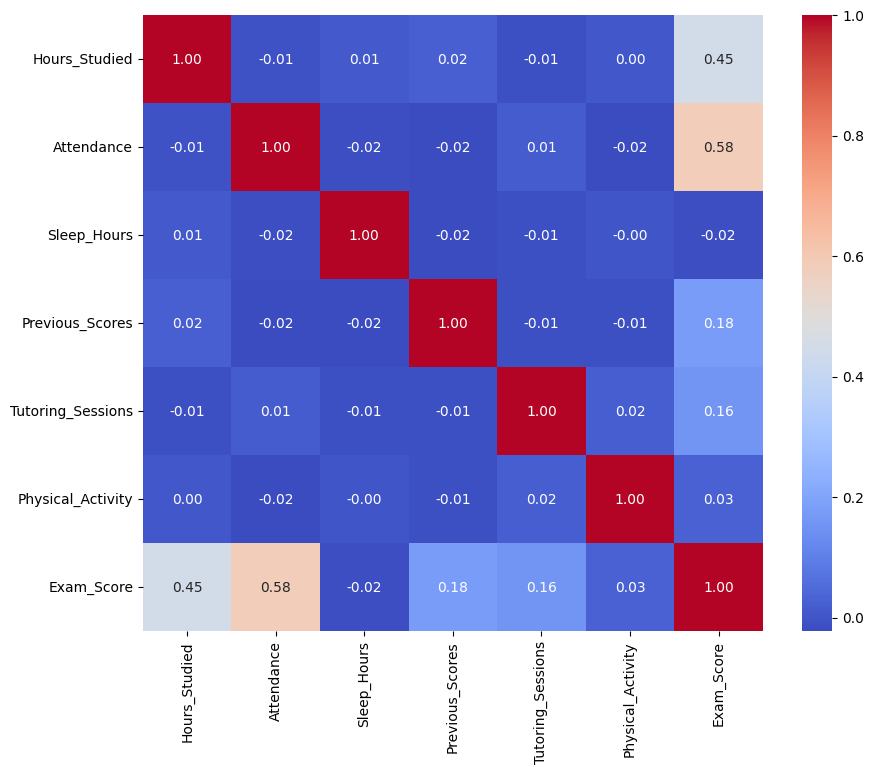

In [13]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [14]:
print((df['Exam_Score'] >= 80).sum())
(df['Exam_Score'] < 80).sum()

48


np.int64(6559)

In [15]:
# Feature Engineering - Create behavioral features

# 1. SUPPORT_INDEX (Destek/Çevre Endeksi)
ordinal_mapping = {
    'Low': 1,
    'Medium': 2, 
    'High': 3,
    'Negative': 1,
    'Neutral': 2,
    'Positive': 3
}

extracurricular_mapping = {'No': 0, 'Yes': 1}

df['Support_Index'] = (
    df['Teacher_Quality'].map(ordinal_mapping) +
    df['Peer_Influence'].map(ordinal_mapping) +
    df['Extracurricular_Activities'].map(extracurricular_mapping)
)

# 2. RESILIENCE_SCORE (Direnç Skoru)
df['Resilience_Score'] = (
    (df['Motivation_Level'] == 'High') &
    (df['Support_Index'] >= 6)
).astype(int)

# 3. INEFFICIENCY_FLAG (Verimsizlik Cezası)
df['Inefficiency_Flag'] = (
    (df['Hours_Studied'] >= df['Hours_Studied'].quantile(0.75)) &
    (df['Previous_Scores'] <= df['Previous_Scores'].quantile(0.25))
).astype(int)

# 4. DISADVANTAGE_SCORE (Dezavantaj Puanı)
disadvantage_map = {'Low': 3, 'Medium': 1, 'High': 0}
df['Disadvantage_Score'] = (
    df['Parental_Involvement'].map(disadvantage_map) +
    df['Access_to_Resources'].map(disadvantage_map) +
    df['Family_Income'].map(disadvantage_map)
)

# 5. EFFORT_PAYOFF (Çalışma Getirisi)
df['Effort_Payoff'] = df['Previous_Scores'] / (df['Hours_Studied'] + 1)

# 6. SLEEP_QUALITY_IMPACT (Uyku Kalitesi Etkisi)
df['Sleep_Quality_Impact'] = df['Sleep_Hours'] * (df['Attendance'] / 100)

# 7. MOTIVATION_SUSTAINABILITY (Motivasyon Sürekliliği)
motivation_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Motivation_Sustainability'] = (
    df['Motivation_Level'].map(motivation_map) * 
    (df['Attendance'] / 100) * 
    (df['Previous_Scores'] / 100)
)

# 8. SUPPORT_MULTIPLIER (Çevre Desteği × Kişisel Çaba)
df['Support_Multiplier'] = df['Support_Index'] * (df['Hours_Studied'] / 20)

# 9. OVERCOMING_ODDS (Engelleri Aşma Gücü)
df['Overcoming_Odds'] = df['Exam_Score'] - (df['Disadvantage_Score'] * 5)

# 10. INTERVENTION_RISK (Müdahale Riski)
df['Intervention_Risk'] = (
    (df['Hours_Studied'] >= 15) &
    (df['Exam_Score'] < 70) &
    (df['Motivation_Level'] == 'High')
).astype(int)

print("New features created:")
print(df[['Support_Index', 'Resilience_Score', 'Inefficiency_Flag', 'Disadvantage_Score', 
          'Effort_Payoff', 'Sleep_Quality_Impact', 'Motivation_Sustainability', 
          'Support_Multiplier', 'Overcoming_Odds', 'Intervention_Risk']].head(10))

New features created:
   Support_Index  Resilience_Score  Inefficiency_Flag  Disadvantage_Score  \
0            5.0                 0                  0                   6   
1            3.0                 0                  0                   5   
2            5.0                 0                  0                   3   
3            4.0                 0                  0                   5   
4            6.0                 0                  0                   3   
5            6.0                 0                  0                   3   
6            5.0                 0                  0                   7   
7            5.0                 0                  1                   3   
8            3.0                 0                  0                   2   
9            7.0                 0                  0                   2   

   Effort_Payoff  Sleep_Quality_Impact  Motivation_Sustainability  \
0       3.041667                  5.88                     0.

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV

X = df.drop('Exam_Score', inplace=False, axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
numeric_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity',
                    'Support_Index', 'Resilience_Score', 'Inefficiency_Flag', 'Disadvantage_Score', 
                    'Effort_Payoff', 'Sleep_Quality_Impact', 'Motivation_Sustainability', 
                    'Support_Multiplier', 'Overcoming_Odds', 'Intervention_Risk']

nominal_features = ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender']

ordinal_features = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home']

ordinal_categories = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'], 
    ['Negative', 'Neutral', 'Positive'],
    ['High School', 'College', 'Postgraduate'],
    ['Near', 'Moderate', 'Far']
]

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror', device='cuda'))
])

In [20]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5, 8, 12],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs = 4,
)

In [21]:
grid_search.fit(X_train, y_train)

/home/aybars_kansu_han/Desktop/aybars/student/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [15:36:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/aybars_kansu_han/Desktop/aybars/student/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [15:36:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Us

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [22]:
print(grid_search.best_params_)

y_pred = grid_search.predict(X_test)

{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


/home/aybars_kansu_han/Desktop/aybars/student/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [15:38:52] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae:.2f} ")
print(f"root mean square error: {rmse:.2f} ")
print(f"r2 : {r2:.2f} ")

mean absolute error: 0.38 
root mean square error: 0.67 
r2 : 0.97 


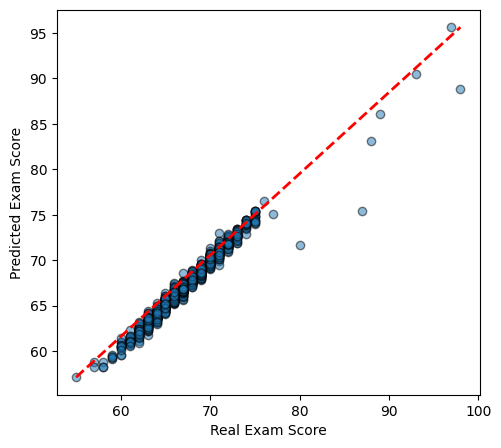

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
plt.xlabel('Real Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()

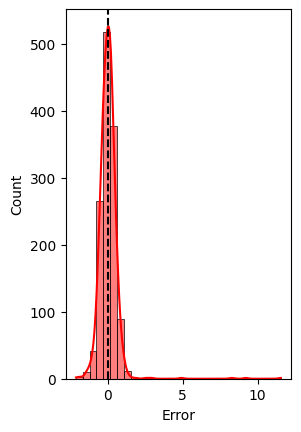

<Figure size 640x480 with 0 Axes>

In [25]:
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='red', bins=30)
plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('Error')
plt.show('Frequency')
plt.tight_layout()

plt.show()

In [26]:
df.iloc[residuals.abs().sort_values(ascending=False).head(7).index]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Support_Index,Resilience_Score,Inefficiency_Flag,Disadvantage_Score,Effort_Payoff,Sleep_Quality_Impact,Motivation_Sustainability,Support_Multiplier,Overcoming_Odds,Intervention_Risk
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,Low,Medium,Public,Negative,3,No,College,Near,Female,87,4.0,0,0,7,4.583333,5.68,0.7810,2.20,52,0
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,Positive,2,No,College,Moderate,Female,98,6.0,0,0,5,3.137931,8.10,1.6380,8.40,73,0
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,Medium,High,Public,Positive,3,No,College,Moderate,Female,80,7.0,1,0,5,4.789474,3.66,1.6653,6.30,55,0
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,Low,High,Private,Neutral,1,No,College,Near,Male,88,5.0,0,0,4,3.157895,6.88,1.0320,4.50,68,0
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89,5.0,0,0,5,2.700000,4.90,1.1340,4.75,64,0
4531,26,69,High,High,No,7,95,Low,No,0,Medium,Medium,Public,Negative,3,No,Postgraduate,Near,Female,93,3.0,0,0,1,3.518519,4.83,0.6555,3.90,88,0
1101,3,62,Medium,Low,No,6,67,Medium,Yes,1,Low,Medium,Public,Negative,3,No,High School,Near,Male,55,3.0,0,0,7,16.750000,3.72,0.8308,0.45,20,0


In [27]:
for i in ordinal_features + nominal_features:
    print(f"{df.iloc[residuals.abs().sort_values(ascending=False).head(7).index][i].value_counts()}\n")

Parental_Involvement
Medium    3
Low       2
High      2
Name: count, dtype: int64

Access_to_Resources
Medium    3
Low       3
High      1
Name: count, dtype: int64

Motivation_Level
Medium    4
High      2
Low       1
Name: count, dtype: int64

Family_Income
Medium    4
Low       3
Name: count, dtype: int64

Teacher_Quality
Medium    5
High      2
Name: count, dtype: int64

Peer_Influence
Negative    3
Positive    3
Neutral     1
Name: count, dtype: int64

Parental_Education_Level
College         4
High School     2
Postgraduate    1
Name: count, dtype: int64

Distance_from_Home
Near        4
Moderate    3
Name: count, dtype: int64

Extracurricular_Activities
No     4
Yes    3
Name: count, dtype: int64

Internet_Access
Yes    6
No     1
Name: count, dtype: int64

School_Type
Public     6
Private    1
Name: count, dtype: int64

Learning_Disabilities
No     6
Yes    1
Name: count, dtype: int64

Gender
Female    4
Male      3
Name: count, dtype: int64



In [28]:
for i in numeric_features:
    print(f"{df.iloc[residuals.abs().sort_values(ascending=False).head(7).index][i].describe()}")

count     7.000000
mean     17.571429
std       8.541217
min       3.000000
25%      14.500000
50%      18.000000
75%      22.500000
max      28.000000
Name: Hours_Studied, dtype: float64
count     7.000000
mean     72.714286
std      11.190983
min      61.000000
25%      65.500000
50%      70.000000
75%      78.500000
max      90.000000
Name: Attendance, dtype: float64
count    7.000000
mean     7.285714
std      1.112697
min      6.000000
25%      6.500000
50%      7.000000
75%      8.000000
max      9.000000
Name: Sleep_Hours, dtype: float64
count     7.000000
mean     73.285714
std      18.354966
min      54.000000
25%      57.500000
50%      67.000000
75%      91.000000
max      95.000000
Name: Previous_Scores, dtype: float64
count    7.000000
mean     1.000000
std      1.154701
min      0.000000
25%      0.000000
50%      1.000000
75%      1.500000
max      3.000000
Name: Tutoring_Sessions, dtype: float64
count    7.000000
mean     2.428571
std      0.786796
min      1.000000
25%

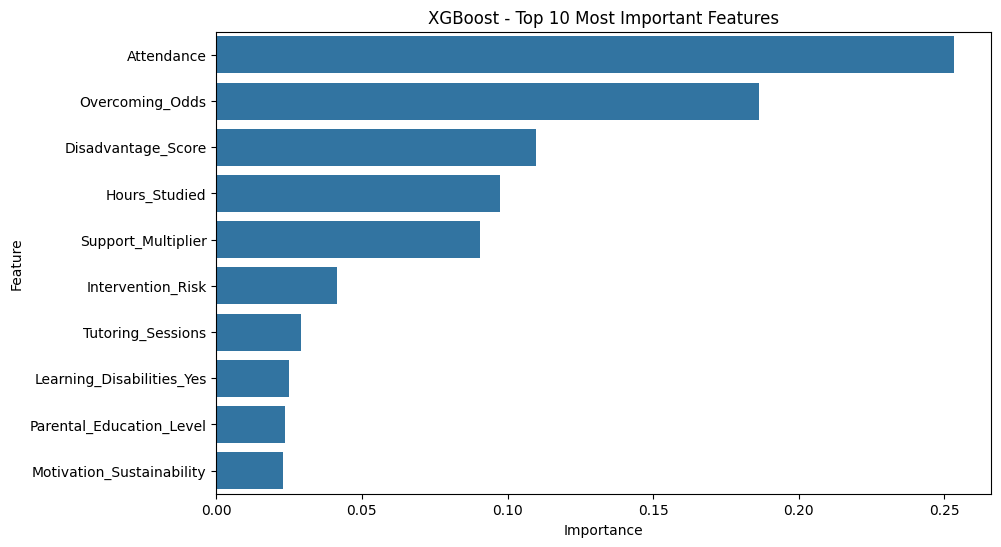

In [29]:
ohe_cols = best_model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)
all_features = numeric_features + list(ohe_cols) + ordinal_features

importances = best_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10))
plt.title('XGBoost - Top 10 Most Important Features')
plt.show()

In [30]:
weights_train = np.where(y_train >= 80, 10, 1)

In [31]:
# grid_search.fit(X_train, y_train, model__sample_weight=weights_train)

In [32]:
grid_search.best_params_

{'model__learning_rate': 0.1,
 'model__max_depth': 5,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

mean absolute error: 0.38 
root mean square error: 0.67 
r2 : 0.97 


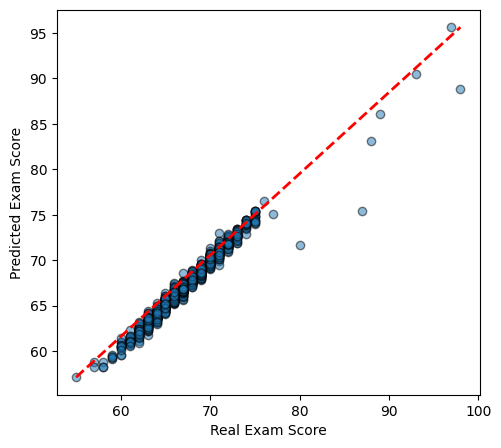

In [33]:
y_pred = grid_search.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae:.2f} ")
print(f"root mean square error: {rmse:.2f} ")
print(f"r2 : {r2:.2f} ")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
plt.xlabel('Real Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()

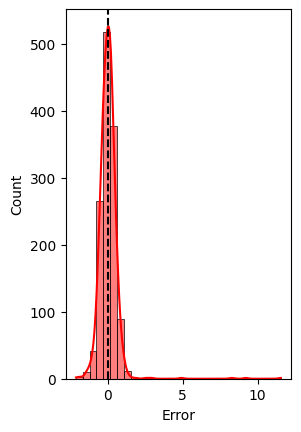

<Figure size 640x480 with 0 Axes>

In [34]:
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='red', bins=30)
plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('Error')
plt.show('Frequency')
plt.tight_layout()

plt.show()

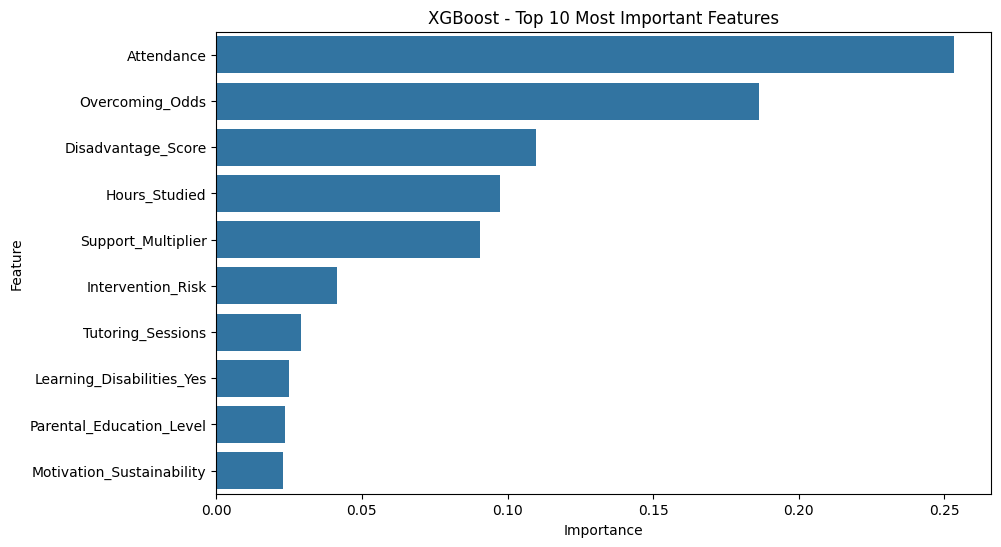

In [35]:
ohe_cols = best_model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)
all_features = numeric_features + list(ohe_cols) + ordinal_features

importances = best_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10))
plt.title('XGBoost - Top 10 Most Important Features')
plt.show()

In [36]:
df.iloc[residuals.sort_values(ascending=False).head(7).index]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Support_Index,Resilience_Score,Inefficiency_Flag,Disadvantage_Score,Effort_Payoff,Sleep_Quality_Impact,Motivation_Sustainability,Support_Multiplier,Overcoming_Odds,Intervention_Risk
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,Low,Medium,Public,Negative,3,No,College,Near,Female,87,4.0,0,0,7,4.583333,5.68,0.7810,2.20,52,0
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,Positive,2,No,College,Moderate,Female,98,6.0,0,0,5,3.137931,8.10,1.6380,8.40,73,0
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,Medium,High,Public,Positive,3,No,College,Moderate,Female,80,7.0,1,0,5,4.789474,3.66,1.6653,6.30,55,0
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,Low,High,Private,Neutral,1,No,College,Near,Male,88,5.0,0,0,4,3.157895,6.88,1.0320,4.50,68,0
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89,5.0,0,0,5,2.700000,4.90,1.1340,4.75,64,0
4531,26,69,High,High,No,7,95,Low,No,0,Medium,Medium,Public,Negative,3,No,Postgraduate,Near,Female,93,3.0,0,0,1,3.518519,4.83,0.6555,3.90,88,0
1615,39,95,Medium,High,Yes,9,54,High,Yes,2,Medium,Medium,Private,Positive,3,No,High School,Moderate,Male,77,6.0,1,1,2,1.350000,8.55,1.5390,11.70,67,0


In [37]:
df[df['Exam_Score'] >= 80]['Gender'].value_counts()

Gender
Male      27
Female    21
Name: count, dtype: int64

In [38]:
unfavorable = df[
    (df['Parental_Involvement'].isin(['Low'])) |
    (df['Access_to_Resources'].isin(['Low'])) |
    (df['Family_Income'].isin(['Low'])) |
    (df['Parental_Education_Level'].isin(['High School']))
]

high_performers = unfavorable[unfavorable['Exam_Score'] >= 80]

low_performers = unfavorable[unfavorable['Exam_Score'] < 70]

In [39]:
print("High Performers (mean):")
print(high_performers[numeric_features].mean())
print("\nLow Performers (mean):")
print(low_performers[numeric_features].mean())

High Performers (mean):
Hours_Studied                19.400000
Attendance                   78.975000
Sleep_Hours                   7.000000
Previous_Scores              73.575000
Tutoring_Sessions             1.500000
Physical_Activity             2.575000
Support_Index                 5.350000
Resilience_Score              0.175000
Inefficiency_Flag             0.100000
Disadvantage_Score            4.175000
Effort_Payoff                 4.025395
Sleep_Quality_Impact          5.523000
Motivation_Sustainability     1.137068
Support_Multiplier            5.222500
Overcoming_Odds              68.525000
Intervention_Risk             0.000000
dtype: float64

Low Performers (mean):
Hours_Studied                18.760346
Attendance                   77.017565
Sleep_Hours                   7.028152
Previous_Scores              73.995910
Tutoring_Sessions             1.403754
Physical_Activity             2.964629
Support_Index                 4.910775
Resilience_Score              0.060154
I

In [40]:
print("high performers \n", high_performers['Learning_Disabilities'].value_counts())
print("low performers \n", low_performers['Learning_Disabilities'].value_counts())

print("high performers \n", high_performers['Motivation_Level'].value_counts())
print("low performers \n", low_performers['Motivation_Level'].value_counts())

print("high performers \n", high_performers['Teacher_Quality'].value_counts())
print("low performers \n", low_performers['Teacher_Quality'].value_counts())

print("high performers \n", high_performers['Peer_Influence'].value_counts())
print("low performers \n", low_performers['Peer_Influence'].value_counts())

print("high performers \n", high_performers['Distance_from_Home'].value_counts())
print("low performers \n", low_performers['Distance_from_Home'].value_counts())

print("high performers \n", high_performers['Extracurricular_Activities'].value_counts())
print("low performers \n", low_performers['Extracurricular_Activities'].value_counts())

print("high performers \n", high_performers['Internet_Access'].value_counts())
print("low performers \n", low_performers['Internet_Access'].value_counts())

print("high performers \n", high_performers['School_Type'].value_counts())
print("low performers \n", low_performers['School_Type'].value_counts())

print("high performers \n", high_performers['Gender'].value_counts())
print("low performers \n", low_performers['Gender'].value_counts())


high performers 
 Learning_Disabilities
No     32
Yes     8
Name: count, dtype: int64
low performers 
 Learning_Disabilities
No     3672
Yes     484
Name: count, dtype: int64
high performers 
 Motivation_Level
Medium    18
High      11
Low       11
Name: count, dtype: int64
low performers 
 Motivation_Level
Medium    2108
Low       1264
High       784
Name: count, dtype: int64
high performers 
 Teacher_Quality
Medium    22
High      16
Low        2
Name: count, dtype: int64
low performers 
 Teacher_Quality
Medium    2492
High      1161
Low        449
Name: count, dtype: int64
high performers 
 Peer_Influence
Positive    18
Neutral     16
Negative     6
Name: count, dtype: int64
low performers 
 Peer_Influence
Neutral     1648
Positive    1571
Negative     937
Name: count, dtype: int64
high performers 
 Distance_from_Home
Near        24
Moderate    11
Far          5
Name: count, dtype: int64
low performers 
 Distance_from_Home
Near        2360
Moderate    1289
Far          465
Name: cou

In [41]:
ordinal_mapping = {
    'Low': 1,
    'Medium': 2, 
    'High': 3,
    'Negative': 1,
    'Neutral': 2,
    'Positive': 3
}

extracurricular_mapping = {'No': 0, 'Yes': 1}

df['Support_Index'] = (
    df['Teacher_Quality'].map(ordinal_mapping) +
    df['Peer_Influence'].map(ordinal_mapping) +
    df['Extracurricular_Activities'].map(extracurricular_mapping)
)

df['Resilience_Score'] = (
    (df['Motivation_Level'] == 'High') &
    (df['Support_Index'] >= 6)
).astype(int)

df['Inefficiency_Flag'] = (
    (df['Hours_Studied'] >= df['Hours_Studied'].quantile(0.75)) &
    (df['Previous_Scores'] <= df['Previous_Scores'].quantile(0.25))
)

disadvantage_map = {'Low': 3, 'Medium': 1, 'High': 0}
df['Disadvantage_Score'] = (
    df['Parental_Involvement'].map(disadvantage_map) +
    df['Access_to_Resources'].map(disadvantage_map) +
    df['Family_Income'].map(disadvantage_map)
)

df['Effort_Payoff'] = df['Previous_Scores'] / (df['Hours_Studied'] + 1)

df['Sleep_Quality_Impact'] = df['Sleep_Hours'] * (df['Attendance'] / 100)

motivation_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Motivation_Sustainability'] = (
    df['Motivation_Level'].map(motivation_map) * 
    (df['Attendance'] / 100) * 
    (df['Previous_Scores'] / 100)
)

df['Support_Multiplier'] = df['Support_Index'] * (df['Hours_Studied'] / 20)

df['Overcoming_Odds'] = df["Previous_Scores"] - (df['Disadvantage_Score'] * 5)

df['Intervention_Risk'] = (
    (df['Hours_Studied'] >= 15) &
    (df['Previous_Scores'] < 70) &
    (df['Motivation_Level'] == 'High')
).astype(int)

In [42]:
numeric_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                    'Tutoring_Sessions', 'Physical_Activity',
                    'Support_Index', 'Resilience_Score', 'Inefficiency_Flag', 
                    'Disadvantage_Score', 'Effort_Payoff', 'Sleep_Quality_Impact',
                    'Motivation_Sustainability', 'Support_Multiplier', 
                    'Overcoming_Odds', 'Intervention_Risk']

In [43]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [44]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num_cols', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror', device='cuda'))
    ]
)

weights_train = np.where(y_train >= 80, 10, 1)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5, 8, 12],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs = 4,
)

In [45]:
grid_search.fit(X_train, y_train)

grid_search.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

mean absolute error: 0.69 
root mean square error: 1.89 
r2 : 0.75 


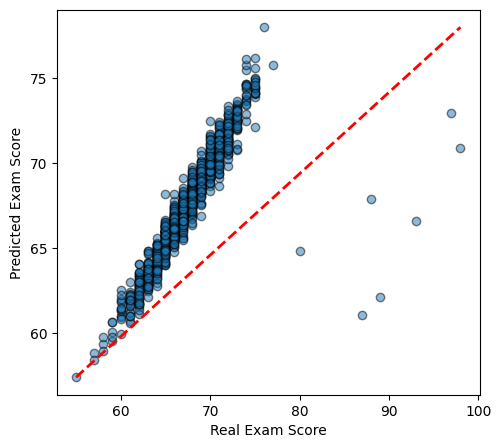

In [46]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae:.2f} ")
print(f"root mean square error: {rmse:.2f} ")
print(f"r2 : {r2:.2f} ")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
plt.xlabel('Real Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()

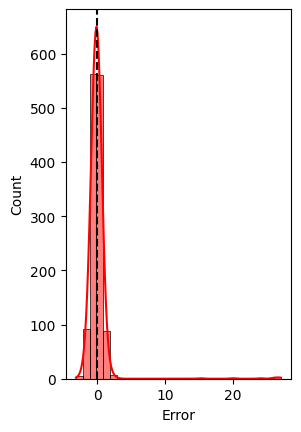

<Figure size 640x480 with 0 Axes>

In [47]:
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='red', bins=30)
plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('Error')
plt.show('Frequency')
plt.tight_layout()

plt.show()

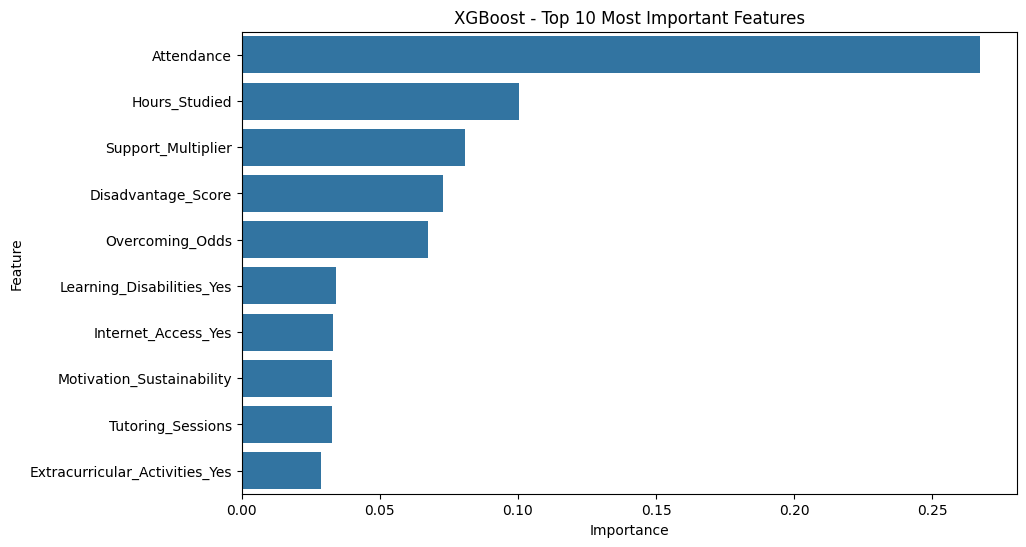

In [48]:
ohe_cols = best_model.named_steps['preprocessor'].transformers_[2][1].named_steps['onehot'].get_feature_names_out(nominal_features)
all_features = numeric_features + list(ohe_cols) + ordinal_features

importances = best_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10))
plt.title('XGBoost - Top 10 Most Important Features')
plt.show()

In [49]:
feature_imp_df

,Feature,Importance
1,Attendance,0.267279
0,Hours_Studied,0.100240
13,Support_Multiplier,0.080845
9,Disadvantage_Score,0.072814
14,Overcoming_Odds,0.067587
19,Learning_Disabilities_Yes,0.034286
17,Internet_Access_Yes,0.032879
12,Motivation_Sustainability,0.032847
4,Tutoring_Sessions,0.032648
16,Extracurricular_Activities_Yes,0.028820


In [50]:
df.iloc[residuals.abs().sort_values(ascending=False).head(7).index]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Support_Index,Resilience_Score,Inefficiency_Flag,Disadvantage_Score,Effort_Payoff,Sleep_Quality_Impact,Motivation_Sustainability,Support_Multiplier,Overcoming_Odds,Intervention_Risk
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,Positive,2,No,College,Moderate,Female,98,6.0,0,False,5,3.137931,8.10,1.6380,8.40,66,0
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89,5.0,0,False,5,2.700000,4.90,1.1340,4.75,29,1
4531,26,69,High,High,No,7,95,Low,No,0,Medium,Medium,Public,Negative,3,No,Postgraduate,Near,Female,93,3.0,0,False,1,3.518519,4.83,0.6555,3.90,90,0
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,Low,Medium,Public,Negative,3,No,College,Near,Female,87,4.0,0,False,7,4.583333,5.68,0.7810,2.20,20,0
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,High,High,Public,Neutral,3,No,High School,Near,Male,97,6.0,0,False,2,2.961538,6.93,1.5246,7.50,67,0
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,Low,High,Private,Neutral,1,No,College,Near,Male,88,5.0,0,False,4,3.157895,6.88,1.0320,4.50,40,0
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,Medium,High,Public,Positive,3,No,College,Moderate,Female,80,7.0,1,False,5,4.789474,3.66,1.6653,6.30,66,0


In [51]:
from sklearn.ensemble import IsolationForest

X_train['Behavior_Gap'] = abs(X_train['Previous_Scores'] - X_train['Attendance'])
X_test['Behavior_Gap'] = abs(X_test['Previous_Scores'] - X_test['Attendance'])

iso = IsolationForest(contamination=0.01, random_state=42)

X_train['Anomaly_Score'] = iso.fit_predict(X_train[numeric_features + ['Behavior_Gap']])

X_test['Anomaly_Score'] = iso.predict(X_test[numeric_features + ['Behavior_Gap']])

numeric_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                    'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 
                    'Resilience_Score', 'Inefficiency_Flag', 'Disadvantage_Score', 
                    'Effort_Payoff', 'Sleep_Quality_Impact', 'Motivation_Sustainability', 
                    'Support_Multiplier', 'Overcoming_Odds', 'Intervention_Risk']
                    
if 'Anomaly_Score' not in numeric_features:
    numeric_features.append('Anomaly_Score')

if 'Behaivor_Gap' not in numeric_features:
    numeric_features.append('Behavior_Gap')

In [52]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num_cols', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ]
)

new_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

grid_search.estimator = new_pipeline


In [53]:
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

mean absolute error: 0.69 
root mean square error: 1.89 
r2 : 0.75 


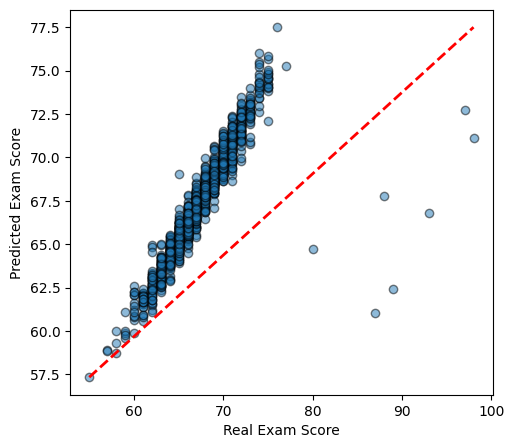

In [54]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae:.2f} ")
print(f"root mean square error: {rmse:.2f} ")
print(f"r2 : {r2:.2f} ")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
plt.xlabel('Real Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()

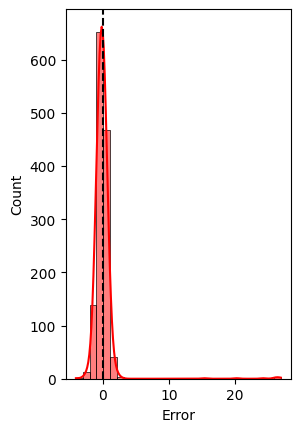

<Figure size 640x480 with 0 Axes>

In [55]:
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='red', bins=30)
plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('Error')
plt.show('Frequency')
plt.tight_layout()

plt.show()

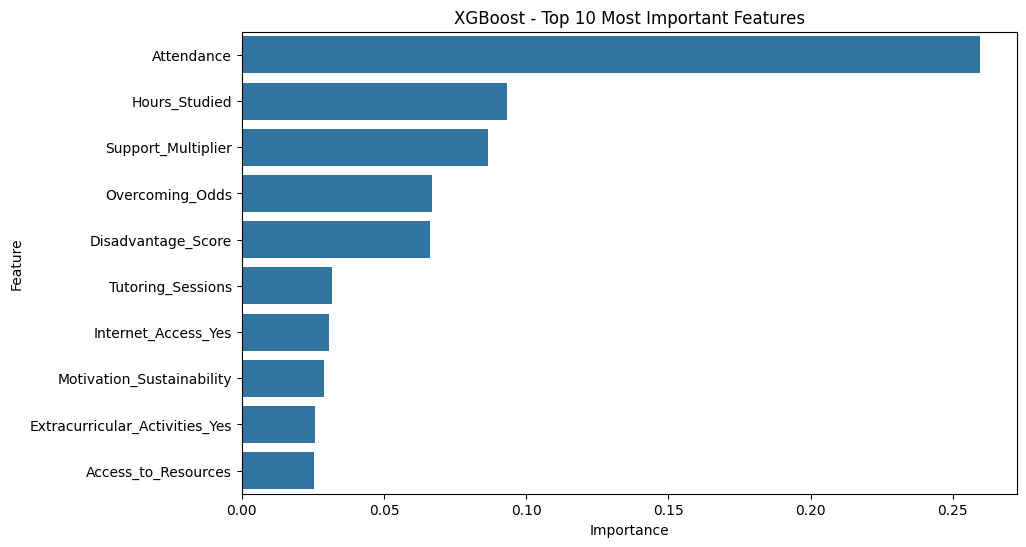

In [56]:
ohe_cols = best_model.named_steps['preprocessor'].transformers_[2][1].named_steps['onehot'].get_feature_names_out(nominal_features)
all_features = numeric_features + list(ohe_cols) + ordinal_features

importances = best_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10))
plt.title('XGBoost - Top 10 Most Important Features')
plt.show()

In [57]:
feature_imp_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
1,Attendance,0.259487
0,Hours_Studied,0.093224
13,Support_Multiplier,0.086476
14,Overcoming_Odds,0.066900
9,Disadvantage_Score,0.066096
4,Tutoring_Sessions,0.031704
19,Internet_Access_Yes,0.030697
12,Motivation_Sustainability,0.029038
18,Extracurricular_Activities_Yes,0.025688
24,Access_to_Resources,0.025244


In [58]:
feature_imp_df

,Feature,Importance
1,Attendance,0.259487
0,Hours_Studied,0.093224
13,Support_Multiplier,0.086476
14,Overcoming_Odds,0.066900
9,Disadvantage_Score,0.066096
4,Tutoring_Sessions,0.031704
19,Internet_Access_Yes,0.030697
12,Motivation_Sustainability,0.029038
18,Extracurricular_Activities_Yes,0.025688
24,Access_to_Resources,0.025244


In [ ]:
important_features = feature_imp_df[feature_imp_df['Importance'] >= 0.01]['Feature'].tolist()
if 'Exam_Score' not in important_features:
    important_features.append('Exam_Score')

In [63]:
existing_cols = [c for c in important_features if c in df.columns]
df_final = df[existing_cols]

In [64]:
df_final.to_csv('filtered_data.csv', index=False)